## Trabajo Práctico
### Modelo de clasificación
#### Aprendizaje Automático I

Estudiantes:
- Ruiz, Irma Carolina
- Quispe, Rocio

**Carga de librerías iniciales**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

**Carga de datos**

In [3]:
data = pd.read_csv('weatherAUS.csv')

### Análisis Exploratorio de Datos

In [4]:
data.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  object 
 1   Location       145460 non-null  object 
 2   MinTemp        143975 non-null  float64
 3   MaxTemp        144199 non-null  float64
 4   Rainfall       142199 non-null  float64
 5   Evaporation    82670 non-null   float64
 6   Sunshine       75625 non-null   float64
 7   WindGustDir    135134 non-null  object 
 8   WindGustSpeed  135197 non-null  float64
 9   WindDir9am     134894 non-null  object 
 10  WindDir3pm     141232 non-null  object 
 11  WindSpeed9am   143693 non-null  float64
 12  WindSpeed3pm   142398 non-null  float64
 13  Humidity9am    142806 non-null  float64
 14  Humidity3pm    140953 non-null  float64
 15  Pressure9am    130395 non-null  float64
 16  Pressure3pm    130432 non-null  float64
 17  Cloud9am       89572 non-null

**Variables Generales**
- Date: Fecha de la observación.
- Location: La ubicación o ciudad en Australia.

**Variables de Temperatura, en °C**
- MinTemp: Temperatura mínima del día.
- MaxTemp: Temperatura máxima del día.
- Temp9am: Temperatura registrada a las 9 de la mañana.
- Temp3pm: Temperatura registrada a las 3 de la tarde.

**Variables de Precipitación y Humedad**
- Rainfall: La cantidad de lluvia registrada ese día, en mm.
- Evaporation: Evaporación de agua de "Clase A" en las 24 horas hasta las 9 am, en milímetros (mm).
- Sunshine: El número de horas de sol brillante durante el día.
- Humidity9am: La humedad relativa a las 9 de la mañana, como un porcentaje.
- Humidity3pm: La humedad relativa a las 3 de la tarde, como un porcentaje.
- RainToday: Indica si hubo precipitación (más de 1 mm) en ese día, o no.

**Variables de Viento**
- WindGustDir: La dirección de la ráfaga de viento más fuerte del día (ej. N, S, SW).
- WindGustSpeed: La velocidad de la ráfaga de viento más fuerte del día, en km/h.
- WindDir9am: La dirección del viento a las 9 de la mañana.
- WindDir3pm: La dirección del viento a las 3 de la tarde.
- WindSpeed9am: La velocidad promedio del viento, a las 9 de la mañana, en km/h.
- WindSpeed3pm: La velocidad promedio del viento a las 3 de la tarde, en km/h.

**Variables Atmosféricas**
- Pressure9am: La presión atmosférica a nivel del mar a las 9 de la mañana, medida en hectopascales (hPa).
- Pressure3pm: La presión atmosférica a las 3 de la tarde, en hPa.
- Cloud9am: La fracción del cielo cubierta por nubes a las 9 de la mañana. Se mide en "oktas", una escala de 0 (cielo completamente despejado) a 8 (cielo completamente cubierto).
- Cloud3pm: La fracción del cielo cubierta por nubes a las 3 de la tarde.

**Variable Objetivo**

*RainTomorrow*: Variable categórica ('Yes'/'No') que responde a la pregunta: "¿Llovió al día siguiente?".

Para agilizar la limpieza, se verifica si hay registros con solo valores nulos.

In [6]:
data.isna().all(axis=1).any()

False

No hay registros solo con datos nulos. Se verifica cuáles tienen nulos y qué porcentaje representa del total.

In [7]:
porc_nulos = data.isnull().sum()/len(data)*100
col_nulos = porc_nulos[porc_nulos>0].sort_values(ascending=False)

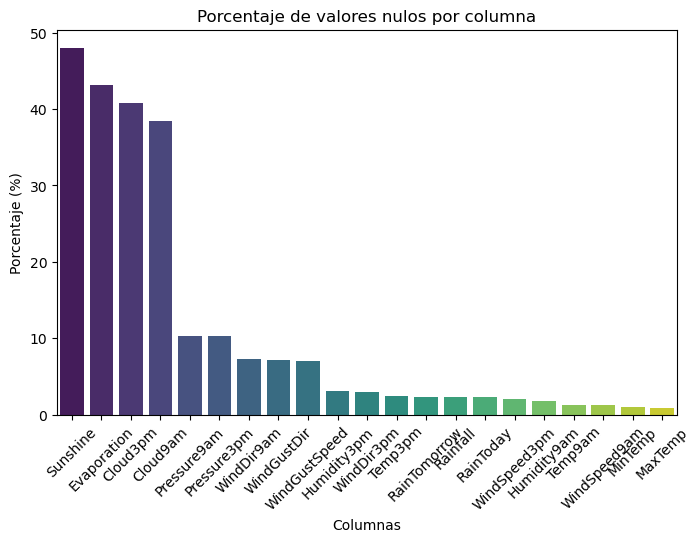

In [8]:
plt.figure(figsize=(8,5))
sns.barplot(x=col_nulos.index, y=col_nulos.values, palette='viridis')

plt.title('Porcentaje de valores nulos por columna')
plt.ylabel('Porcentaje (%)')
plt.xlabel('Columnas')
plt.xticks(rotation=45)
plt.show()

Distribución de datos numéricos en histogramas y outliers.

In [9]:
data_num = data[['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine', 'WindGustSpeed', 
                 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm',
                 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm']]

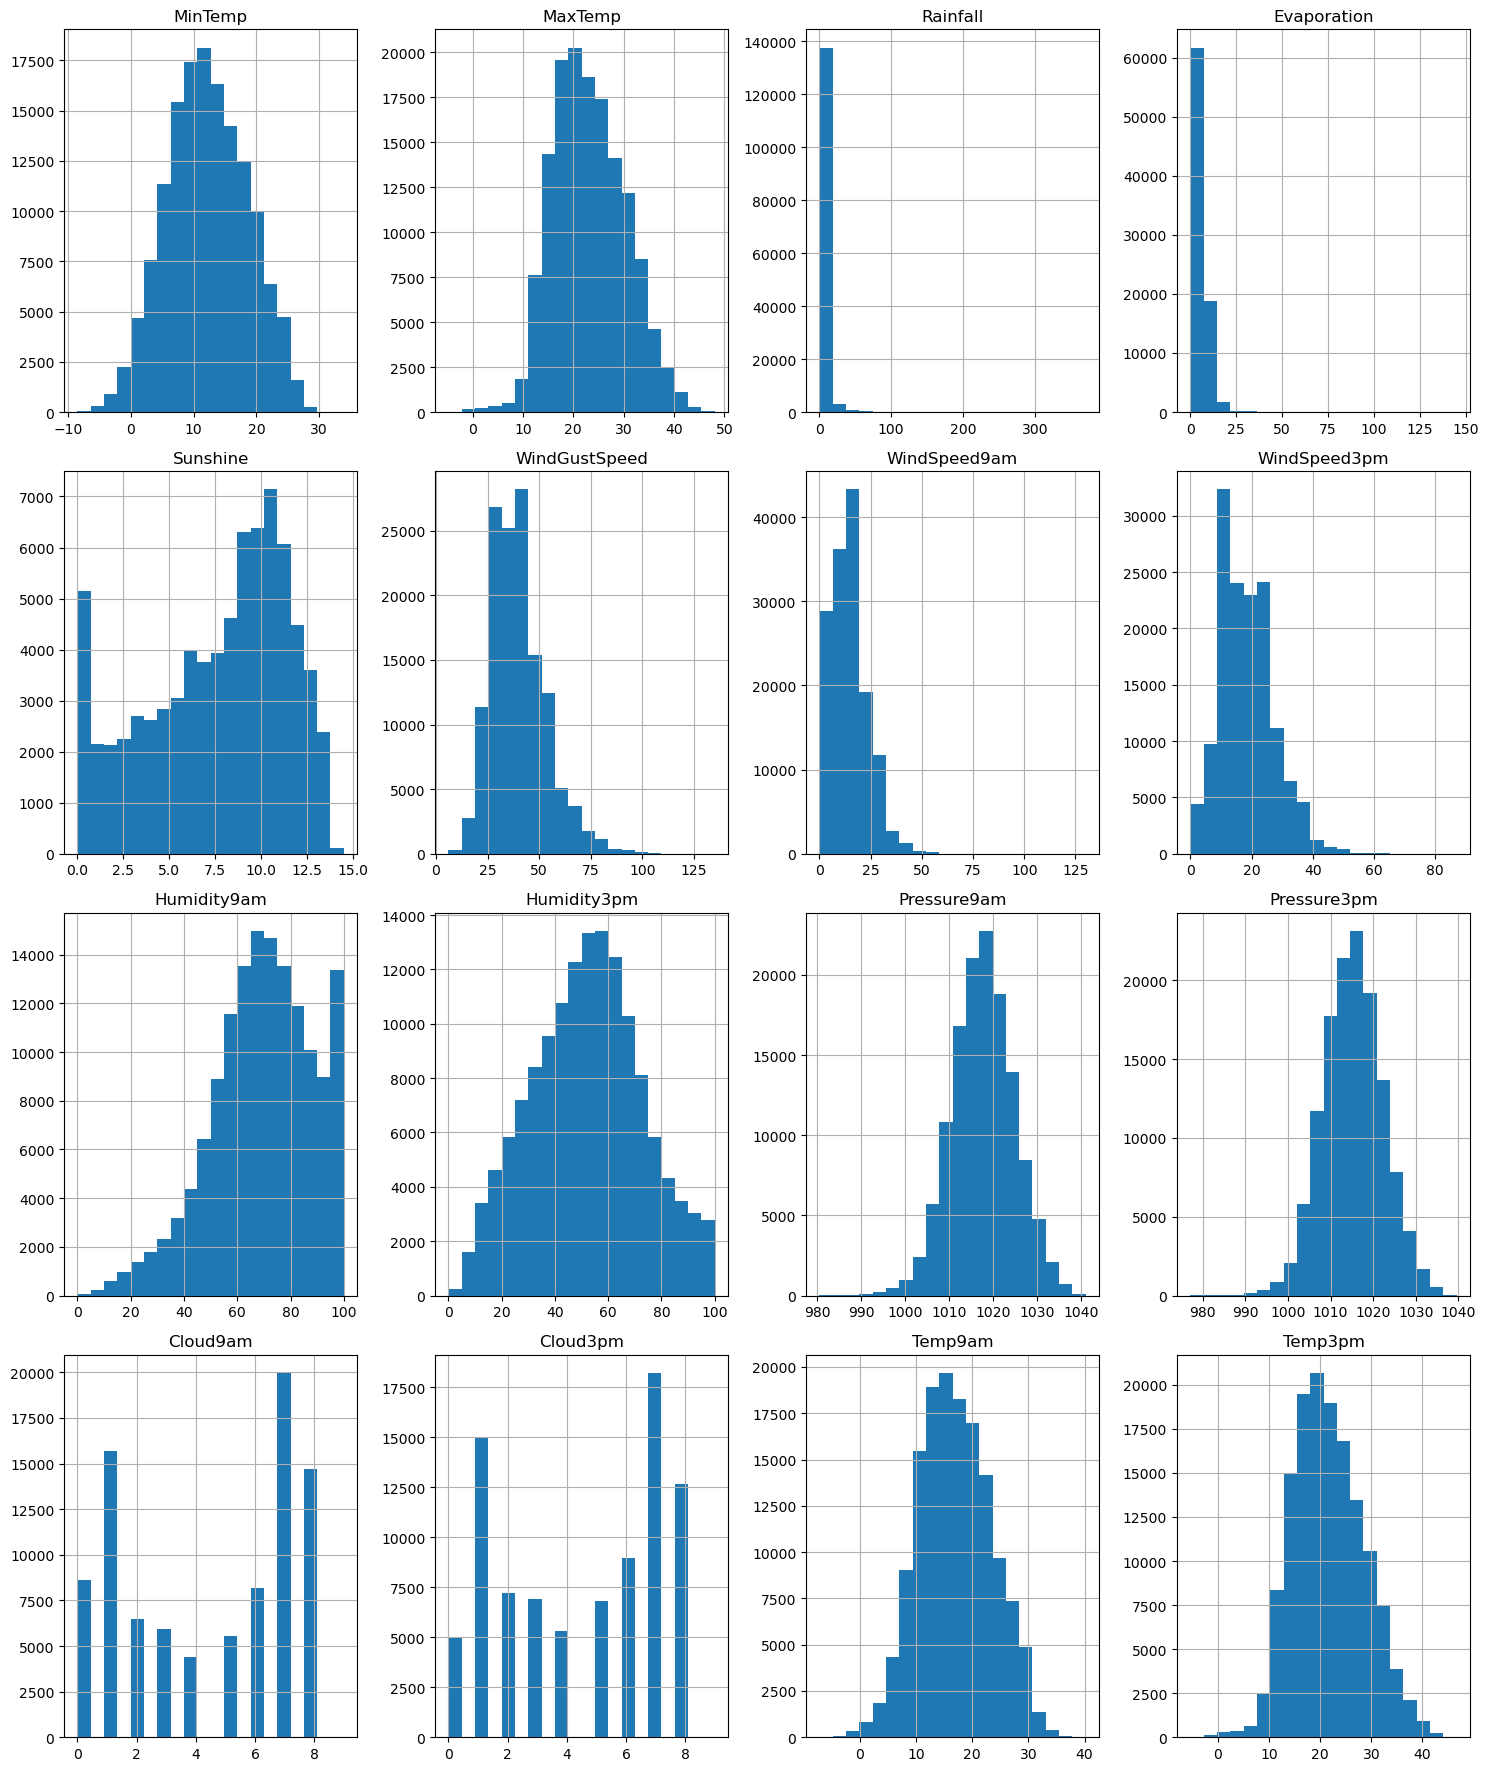

In [10]:
data_num.hist(figsize=(15, 22), bins=20, layout=(5, 4))
plt.tight_layout()
plt.show()

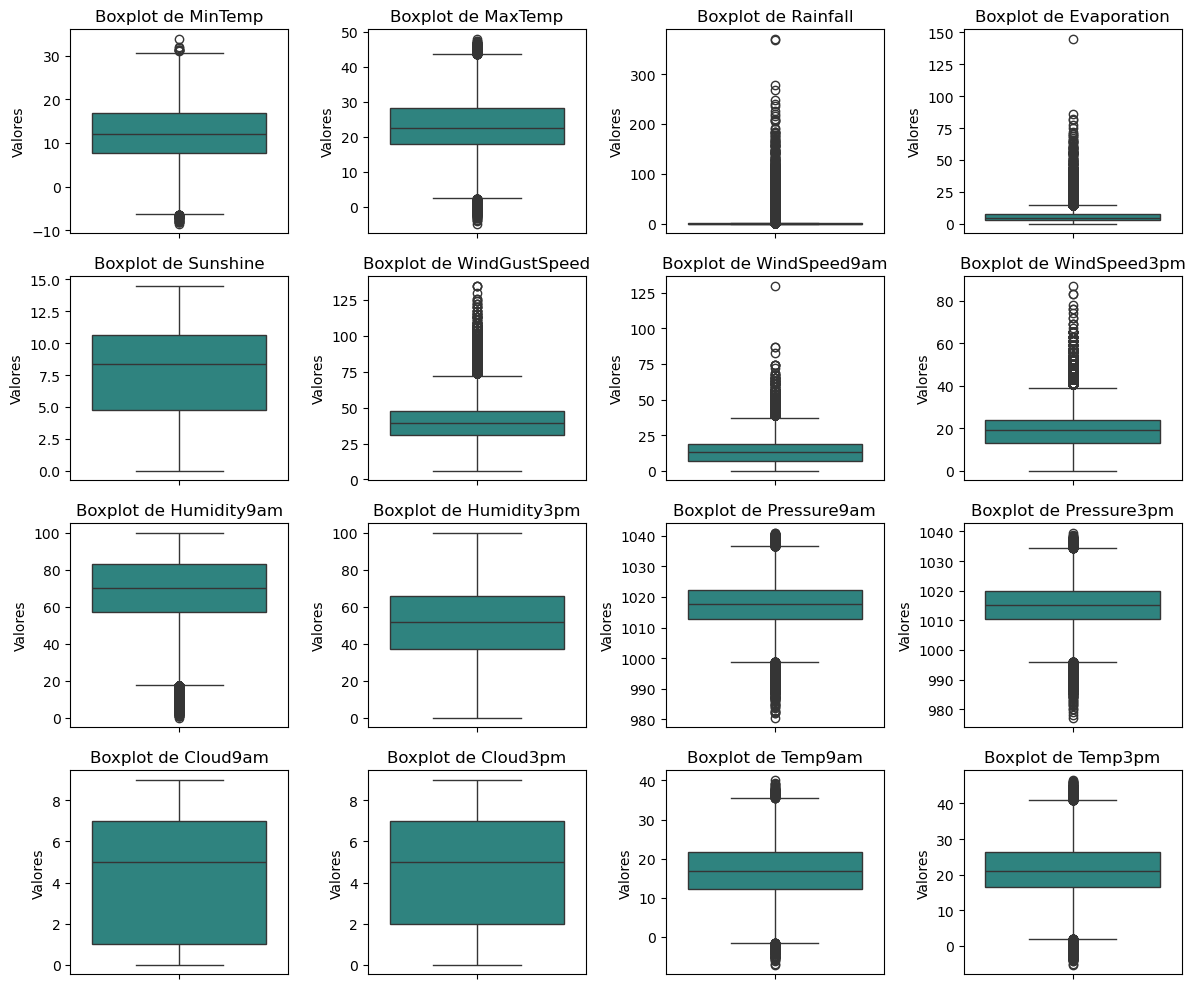

In [11]:
columnas = data_num.columns

fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(12, 10))
axes = axes.flatten()

for i, col in enumerate(columnas):
    sns.boxplot(y=data_num[col], ax=axes[i], palette='viridis')
    axes[i].set_title(f'Boxplot de {col}')
    axes[i].set_ylabel('Valores')

plt.tight_layout()
plt.show()

**Grupo de Temperaturas (MinTemp, MaxTemp, Temp9am, Temp3pm)**

Todas las variables de temperatura muestran distribuciones bastante simétricas. MaxTemp es casi perfectamente simétrica. MinTemp, en cambio, tiene una ligera asimetría izquierda (cola izquierda), con varios outliers en el extremo frío. Esto sugiere que las temperaturas mínimas inusualmente bajas son más comunes que las máximas inusualmente altas.

Temp9am vs Temp3pm: Ambas son muy simétricas, parecidas a MaxTemp. Tienen outliers en ambos extremos, lo cual es normal para mediciones de temperatura.

**Grupo de Humedad (Humidity9am, Humidity3pm)**

Humidity9am: Muestra una fuerte asimetría izquierda. La "caja" está aplastada en la parte superior del gráfico, lo que significa que la mayoría de las mañanas la humedad es muy alta (entre 70% y 90%). Los outliers son todos valores bajos.

Humidity3pm: Es la variable más simétrica y "limpia" de todas. Tiene una distribución casi normal, centrada alrededor del 50%-60%, y casi sin outliers.

Los datos muestran un patrón: la humedad es alta y poco variable por la mañana, pero baja y se "normaliza" por la tarde.

**Grupo de Presión Atmosférica (Pressure9am, Pressure3pm)**

Ambas presentan una clara asimetría izquierda. La mediana está en la mitad superior de la caja, y el bigote inferior es mucho más largo. Ambas tienen una fuerte presencia de outliers en el extremo inferior.

**Grupo de Viento (WindGustSpeed, WindSpeed9am, WindSpeed3pm)**

Todas tienen una fuerte asimetría derecha (cola derecha). La "caja" está comprimida en valores bajos, lo que indica que la mayoría del tiempo el viento es leve. Todas tienen una enorme cantidad de outliers en el extremo superior. Esos outliers representan los días de viento o ráfagas fuertes.

9am vs 3pm: La mediana y la caja de WindSpeed3pm están ligeramente más altas que en WindSpeed9am, sugiriendo que, en general, hay más viento por la tarde.

**Grupo de Agua (Rainfall, Evaporation)**

Rainfall: La "caja" (el 50% central de los datos) es una línea plana en cero. Esto significa que al menos el 75% de los días no llueve nada. Los outliers son la lluvia.

Evaporation: Similar a Rainfall, la caja está totalmente comprimida en la parte inferior. La mayoría de los valores son muy bajos.

**Grupo de Cielo (Sunshine, Cloud9am, Cloud3pm)**

Sunshine: distribución bimodal. La caja está aplastada en la parte superior (días de mucho sol), y el bigote inferior se extiende hasta 0 (días sin sol).

Cloud9am y Cloud3pm: No tienen outliers y los bigotes se extienden por todo el rango (de 0 a 8 o 9).

Detalle a tener en cuenta: Cloud9am y Cloud3pm son variables discretas (probablemente "octas" de cielo cubierto, de 0 a 8).


Detalles sobre las columnas categóricas.

In [12]:
data_cat = data[['Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday', 'RainTomorrow']]

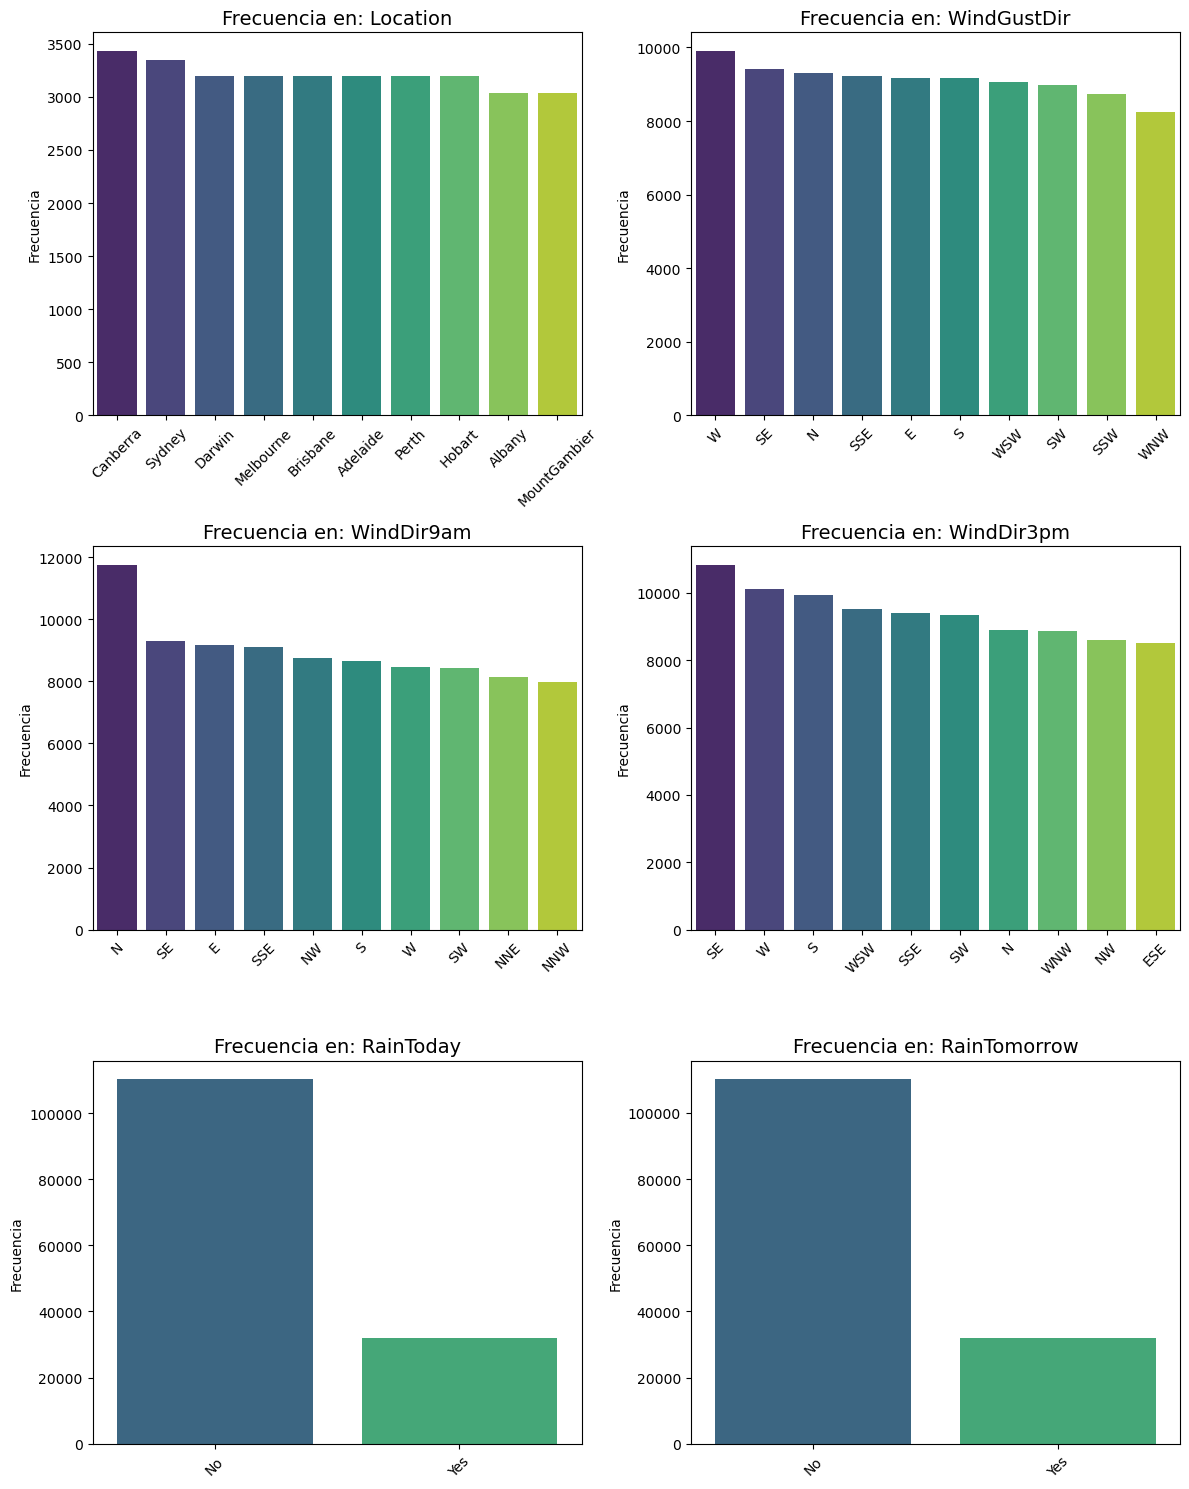

In [13]:
import math

n_cols = 2
n_rows = math.ceil(data_cat.shape[1] / n_cols)

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(12, n_rows * 5))
axes = axes.flatten()

# Se itera sobre cada columna categórica y crear su gráfico
for i, col in enumerate(data_cat.columns):
    top_cat = data_cat[col].value_counts().nlargest(10)
    
    sns.barplot(x=top_cat.index, y=top_cat.values, ax=axes[i], palette='viridis')
    axes[i].set_title(f'Frecuencia en: {col}', fontsize=14)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Frecuencia')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Las variables categóricas relacionadas a WindDir y WindGus se dividen en los puntos cardinales de los cuales provienen los vientos. No parece hacer categorías sin valores. Por otro lado, las variables relacionadas a Rain solo tienen dos categorías que podrían ser transformadas en numéricas 1/0 para su uso en un modelo predictivo.

En este sentido, ya que **RainTomorrow** va a ser la variable objetivo, se puede suponer que está desbalanceada al haber más datos de 'No' que de 'Yes'. Esto indica que posiblemente deberá trabajarse para que no afecte a las predicciones.

---

### División del dataset en train-val-test

In [14]:
from sklearn.model_selection import train_test_split

Teniendo en cuenta el análisis sobre los datos nulos por columna visto previamente, se resuelve que imputar a las columnas que tienen 40% o más de nulos, no tiene sentido. Por lo tanto, se eliminarán de las variables predictoras (X). Asimismo, solo se eliminarán 3267 registros nulos de 'RainTomorrow' (futura variable objetivo) para que no cause problemas en el split. Esto representaría el apróx. 2,25% de los registros del dataset original.

In [15]:
data['RainTomorrow'].isna().sum()

3267

In [16]:
data = data.dropna(subset=['RainTomorrow'])

In [17]:
X = data.drop(columns=['RainTomorrow', 'Sunshine', 'Evaporation', 'Cloud3pm', 'Cloud9am'], axis=1)
Y = data['RainTomorrow']

In [18]:
# División provisoria
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, Y,
    test_size=0.2,   # 20% para el test set final
    random_state=42,
    stratify=Y)

# División final
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val,
    test_size=0.25,
    random_state=42,
    stratify=y_train_val)

# Proporción final: X_train: 60%, X_val: 20%, X_test: 20%

In [19]:
print(f"""Conjunto de entrenamiento: x_train: {X_train.shape}, y_train: {y_train.shape[0]}
Conjunto de validación: x_val: {X_val.shape}, y_val: {y_val.shape[0]}
Conjunto de prueba: x_test: {X_test.shape}, y_test: {y_test.shape[0]}""")

Conjunto de entrenamiento: x_train: (85315, 18), y_train: 85315
Conjunto de validación: x_val: (28439, 18), y_val: 28439
Conjunto de prueba: x_test: (28439, 18), y_test: 28439


Se incluye una visualización sobre la correlación de las variables numéricas de X_train.

In [22]:
colum_numer_final = ['MinTemp', 'MaxTemp', 'Rainfall',
'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am',
'Humidity3pm', 'Pressure9am', 'Pressure3pm','Temp9am', 'Temp3pm']

corr_matrix = X_train[colum_numer_final].corr()

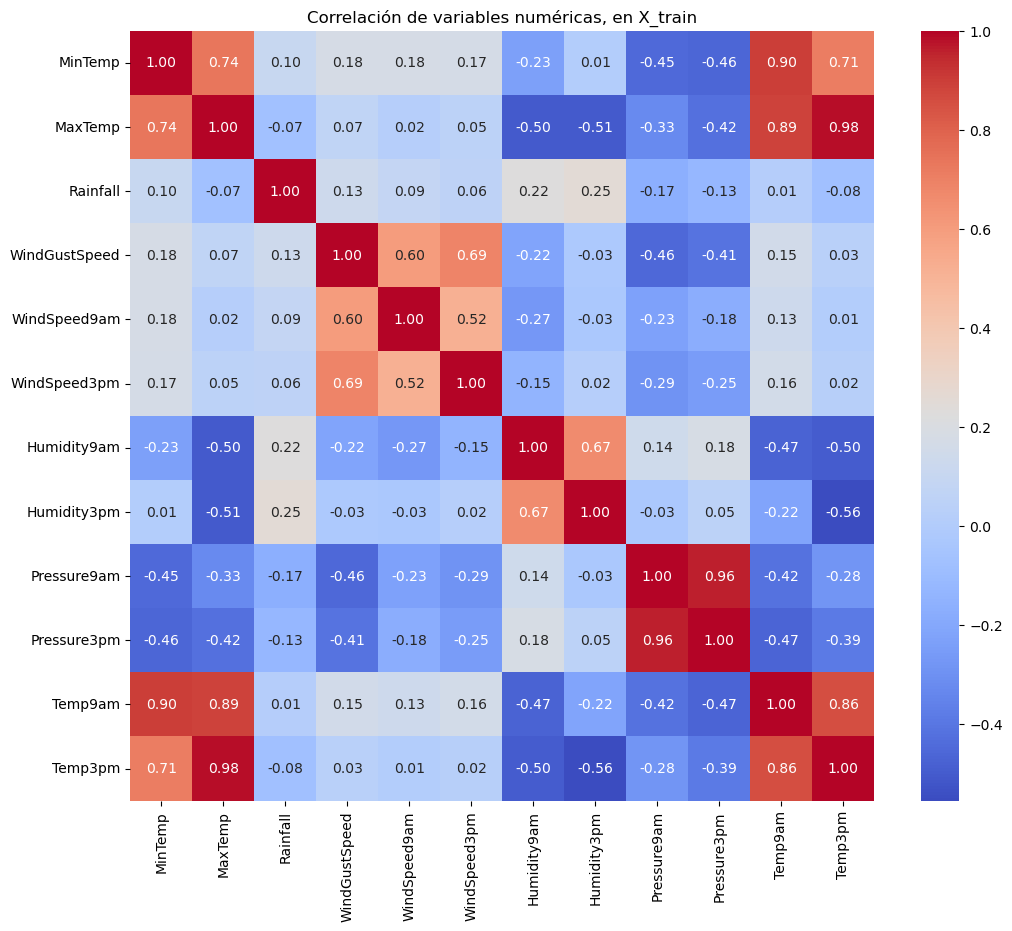

In [24]:
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlación de variables numéricas, en X_train')
plt.show()

---

### Imputación de datos faltantes y transformación de datos

In [20]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn import set_config

Como aún quedan columnas con nulos, se dividirán para imputarlas por separado, según su naturaleza vista en el EDA.

In [21]:
colum_num = ['WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Rainfall',
                  'MinTemp', 'MaxTemp', 'Humidity9am', 'Humidity3pm', 
                  'Pressure9am', 'Pressure3pm', 'Temp9am', 'Temp3pm']

colum_categ = ['WindDir9am', 'WindDir3pm', 'WindGustDir', 'RainToday']

In [22]:
set_config(transform_output="pandas")

In [23]:
imputador = ColumnTransformer(
    transformers=[
        ('num_imputer', SimpleImputer(strategy='median'), colum_num),
        ('cat_imputer', SimpleImputer(strategy='most_frequent'), colum_categ)
    ],
    remainder='passthrough'
)

Las variables categóricas se imputan por la moda y las numéricas, por la mediana. Se aplican los cambios a X_train y se transforman los demás conjuntos X.

In [24]:
imputador.fit(X_train)

X_train = imputador.transform(X_train)
X_val = imputador.transform(X_val)
X_test = imputador.transform(X_test)

Se aplica una transformación logarítmica (específicamente np.log1p) a las variables WindGustSpeed, WindSpeed9am, WindSpeed3pm y Rainfall. Esta decisión se basa en el EDA, el cual reveló que dichas variables poseían una fuerte asimetría positiva (cola a la derecha).

In [ ]:
cols_transf_log = ['num_imputer__WindGustSpeed', 'num_imputer__WindSpeed9am', 
                   'num_imputer__WindSpeed3pm', 'num_imputer__Rainfall']

X_train[cols_transf_log] = np.log1p(X_train[cols_transf_log])
X_val[cols_transf_log] = np.log1p(X_val[cols_transf_log])
X_test[cols_transf_log] = np.log1p(X_test[cols_transf_log])

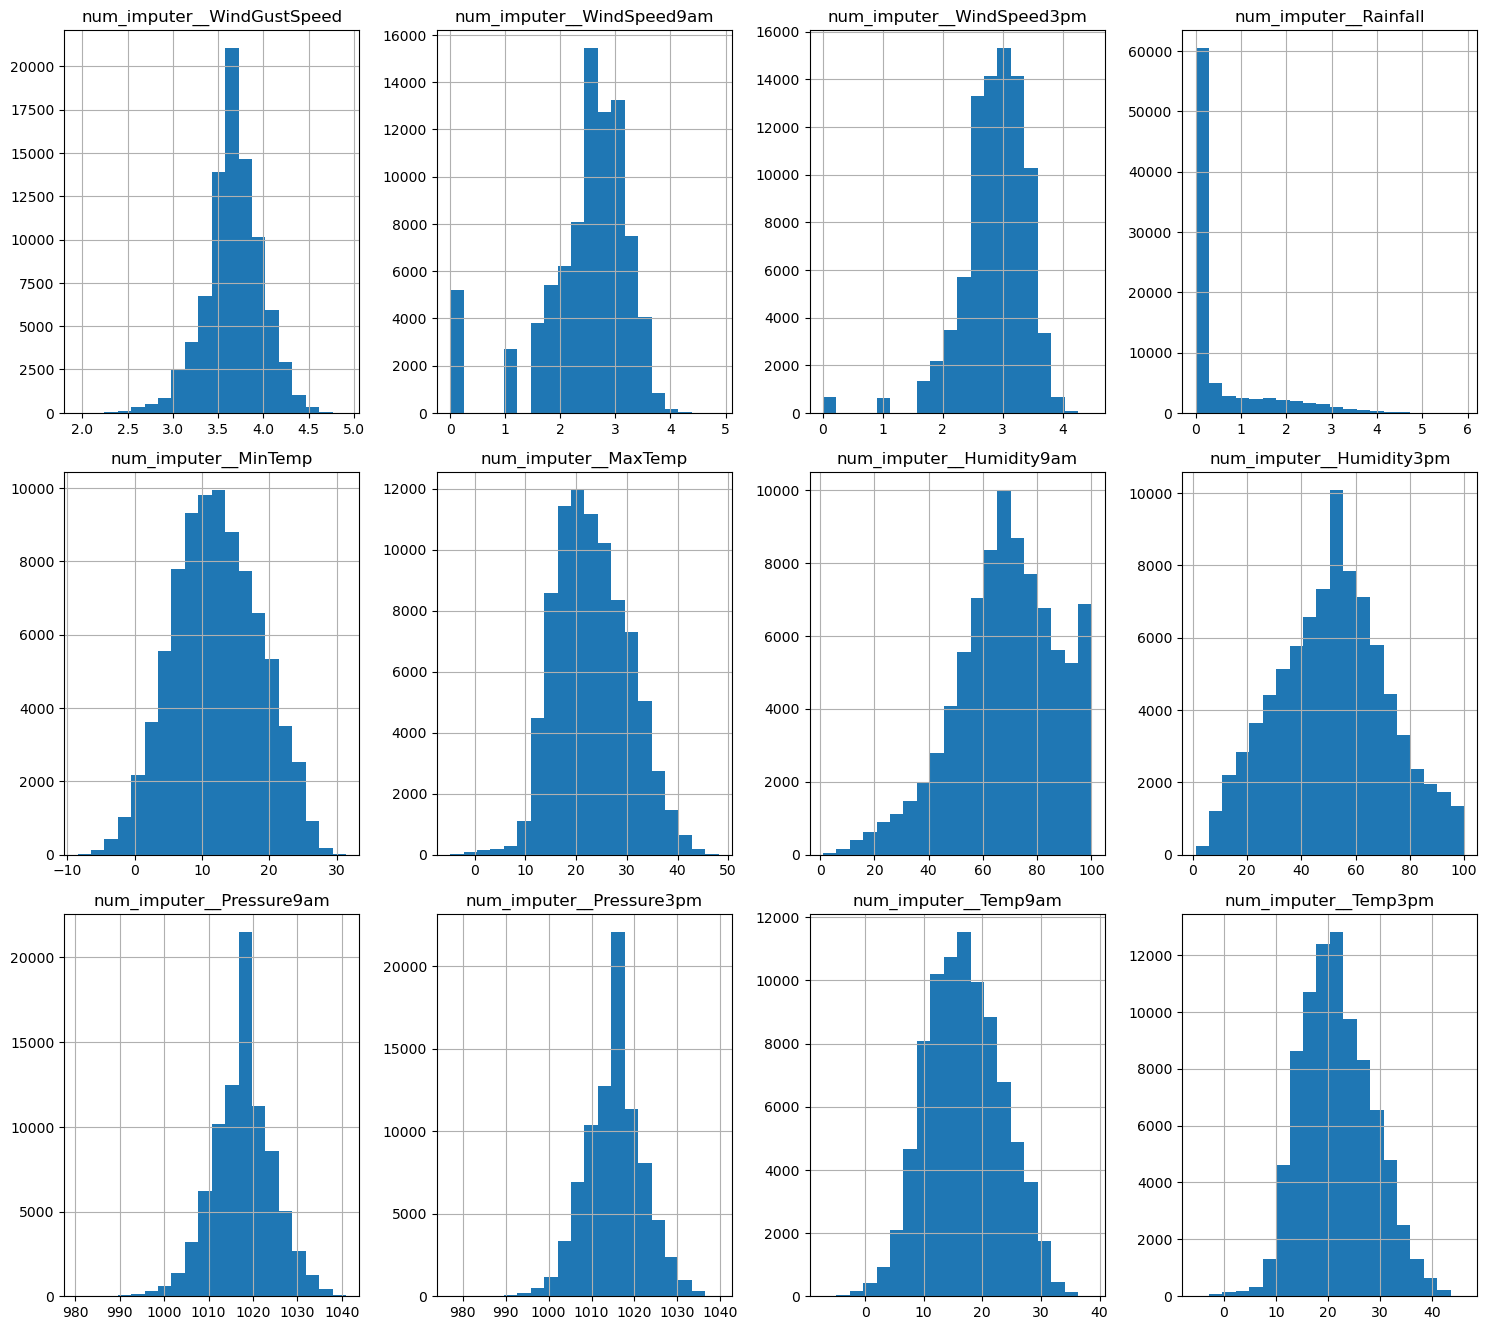

In [29]:
X_train.hist(figsize=(15, 22), bins=20, layout=(5, 4))
plt.tight_layout()
plt.show()

Las distribuciones de las variables de viento (WindGustSpeed, etc.) se volvieron mucho más simétricas y centradas. En Rainfall, aunque se mantiene una gran cantidad de ceros, el impacto de los valores extremos de lluvia fue drásticamente reducido, agrupándolos en un rango mucho más manejable.

---

---

### Al ser relevantes, se continúa buscando más información sobre las ciudades del dataset. Como solo se cuenta con sus nombres, se buscan sus latitudes y longitudes para visualizarlas.

In [ ]:
data_limpio['Location'] = data_limpio['Location'].str.strip()

In [ ]:
import geonamescache

In [ ]:
gc = geonamescache.GeonamesCache()
ciudades = gc.get_cities()
ciudades_df = pd.DataFrame(ciudades).T

In [ ]:
ciudades_df = ciudades_df[["name", "countrycode", "latitude", "longitude"]]
ciudades_df.rename(columns={"name": "Location"}, inplace=True)

In [ ]:
data_completo = pd.merge(data_limpio, ciudades_df, on='Location', how='left')

Visualización de ciudades en mapa

In [ ]:
import geopandas as gpd
import contextily as ctx

In [ ]:
def crear_geodf(df, lon_col="longitude", lat_col="latitude"):
    """
    Convierte un DataFrame con columnas de latitud/longitud
    en un GeoDataFrame en proyección métrica (EPSG:3857)
    """
    gdf = gpd.GeoDataFrame(
        df,
        geometry=gpd.points_from_xy(df[lon_col], df[lat_col]),
        crs="EPSG:4326"  # coordenadas geográficas
    )
    return gdf.to_crs(epsg=3857)

In [ ]:
gdf = crear_geodf(data_completo)

In [ ]:
def graf_mapa(geodf, titulo):
    fig, ax = plt.subplots(figsize=(10, 8))
    geodf.plot(ax=ax, color='red', markersize=60)

    # Mapa base
    ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)

    # Límites del mapa
    ax.set_xlim(geodf.total_bounds[0] - 1e6, geodf.total_bounds[2] + 1e6)
    ax.set_ylim(geodf.total_bounds[1] - 1e6, geodf.total_bounds[3] + 1e6)

    ax.set_title(titulo, fontsize=14)
    plt.show()

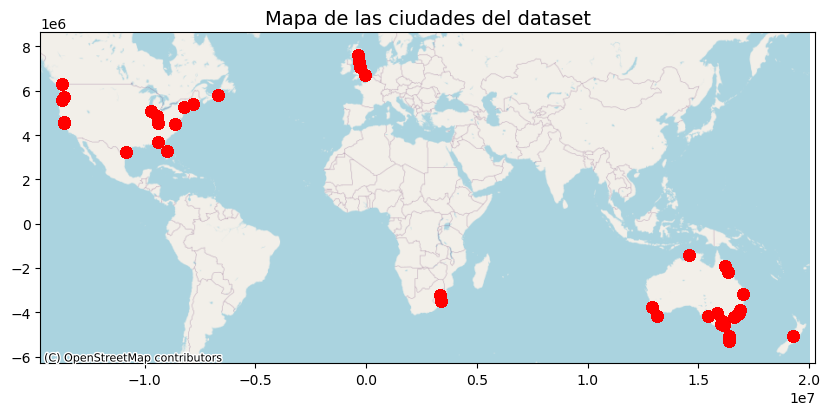

In [ ]:
titulo = 'Mapa de las ciudades del dataset'
graf_mapa(gdf, titulo)

Como el presente análisis solo se centrará en Australia, se limitará a las ciudades situadas entre:
- Latitud: entre -44 y -10
- Longitud: entre 113 y 154.

In [ ]:
def in_aus(lat, lon):
    return -44 <= lat <= -10 and 113 <= lon <= 154

# Filtro solo Australia
mask = data_completo.apply(lambda row: in_aus(row['latitude'], row['longitude']), axis=1)

data_aus = data_completo[mask].copy()

In [ ]:
gdf = crear_geodf(data_aus)

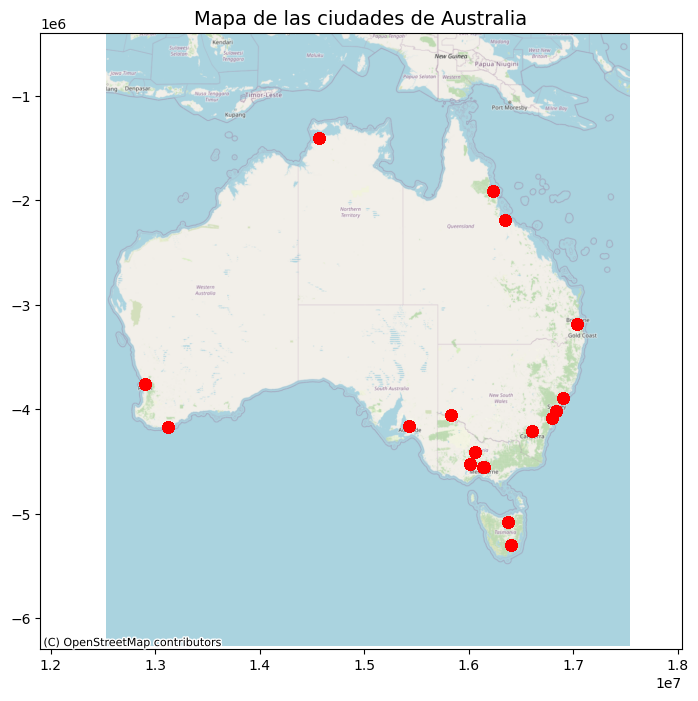

In [ ]:
titulo = 'Mapa de las ciudades de Australia'
graf_mapa(gdf, titulo)

Ahora que solo quedaron los datos relacionados a Australia, se continúa con la clusterización de las regiones. Se hipotetiza que se propia dividir el mapa en cuatro regiones (norte, sur, este y oeste) pero se verificará con el método del codo.

In [ ]:
from sklearn.cluster import KMeans

In [ ]:
x = data_aus[['latitude', 'longitude']]

Exception in thread Thread-5 (_readerthread):
Traceback (most recent call last):
  File "d:\Programas\anaconda3\envs\Python_ML\lib\threading.py", line 1016, in _bootstrap_inner
    self.run()
  File "d:\Programas\anaconda3\envs\Python_ML\lib\threading.py", line 953, in run
    self._target(*self._args, **self._kwargs)
  File "d:\Programas\anaconda3\envs\Python_ML\lib\subprocess.py", line 1515, in _readerthread
    buffer.append(fh.read())
  File "d:\Programas\anaconda3\envs\Python_ML\lib\codecs.py", line 322, in decode
    (result, consumed) = self._buffer_decode(data, self.errors, final)
UnicodeDecodeError: 'utf-8' codec can't decode byte 0xa2 in position 106: invalid start byte
d:\Programas\anaconda3\envs\Python_ML\lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python p

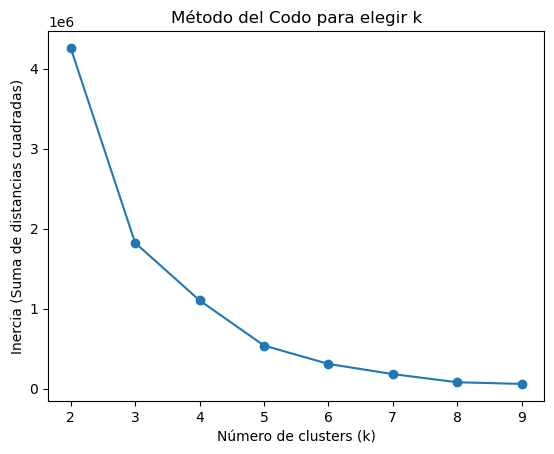

In [ ]:
inertias = []
for k in range(2, 10):
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(x)
    inertias.append(km.inertia_)

plt.plot(range(2, 10), inertias, marker='o')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Inercia (Suma de distancias cuadradas)')
plt.title('Método del Codo para elegir k')
plt.show()

El método del codo demuestra que es mejor 6 que 4. Se graficará esta idea.

In [ ]:
k = 6
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
data_aus['region_cluster'] = kmeans.fit_predict(x)

Graficación de resultados de clusters

In [ ]:
gdf = crear_geodf(data_aus)

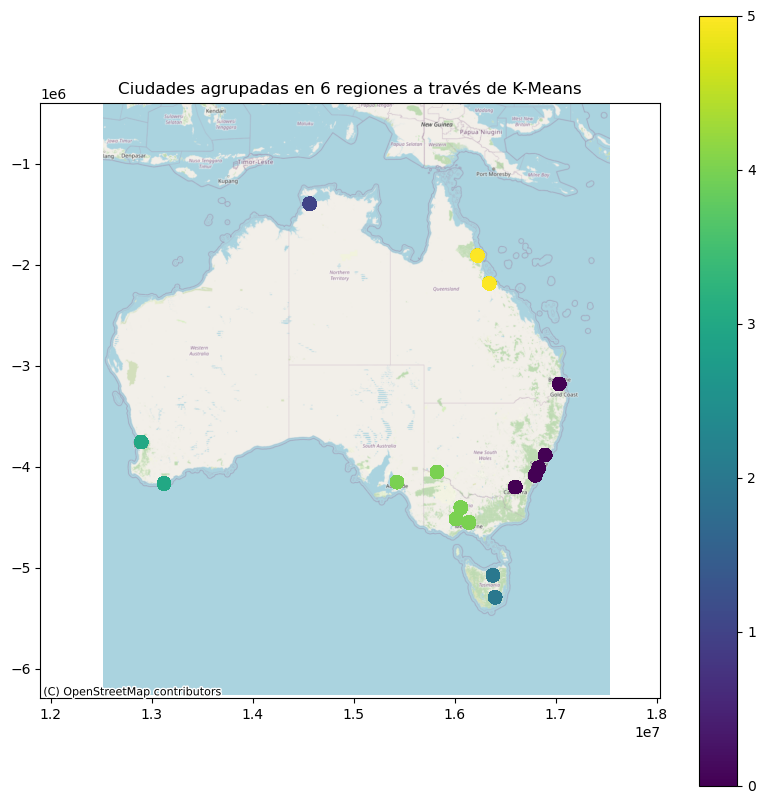

In [ ]:
fig, ax = plt.subplots(figsize=(10, 10))
gdf.plot(ax=ax, column="region_cluster", legend=True, markersize=80, alpha=0.9)
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)
ax.set_xlim(gdf.total_bounds[0] - 1e6, gdf.total_bounds[2] + 1e6)
ax.set_ylim(gdf.total_bounds[1] - 1e6, gdf.total_bounds[3] + 1e6)
ax.set_title(f"Ciudades agrupadas en {k} regiones a través de K-Means", fontsize=12)
plt.show()

Se eliminan las columnas que se consideran innecesarias y se procede a trabajar sobre otras potencialmente útiles que no fueron observadas, como Date.

In [ ]:
data_aus = data_aus.drop(columns=['Location', 'countrycode', 'latitude', 'longitude'])

In [ ]:
data_aus['month'] = data_aus['Date'].dt.month
estaciones = {
    12: 'Verano', 1: 'Verano', 2: 'Verano',
    3: 'Otoño', 4: 'Otoño', 5: 'Otoño',
    6: 'Invierno', 7: 'Invierno', 8: 'Invierno',
    9: 'Primavera', 10: 'Primavera', 11: 'Primavera'
}

In [ ]:
data_aus['season'] = data_aus['month'].map(estaciones)

In [ ]:
data_aus =  data_aus.drop(columns=['month', 'Date'])

Si bien aun hay variables que deben reverse, se considera que es momento de escalar los datos numéricos. Se chequean sus distribuciones en boxplots. Si hay varias columnas con outliers, se procederá a escalar con **RobustScaler** para escalar en base a la mediana y los cuartiles, luego del split para el modelo.

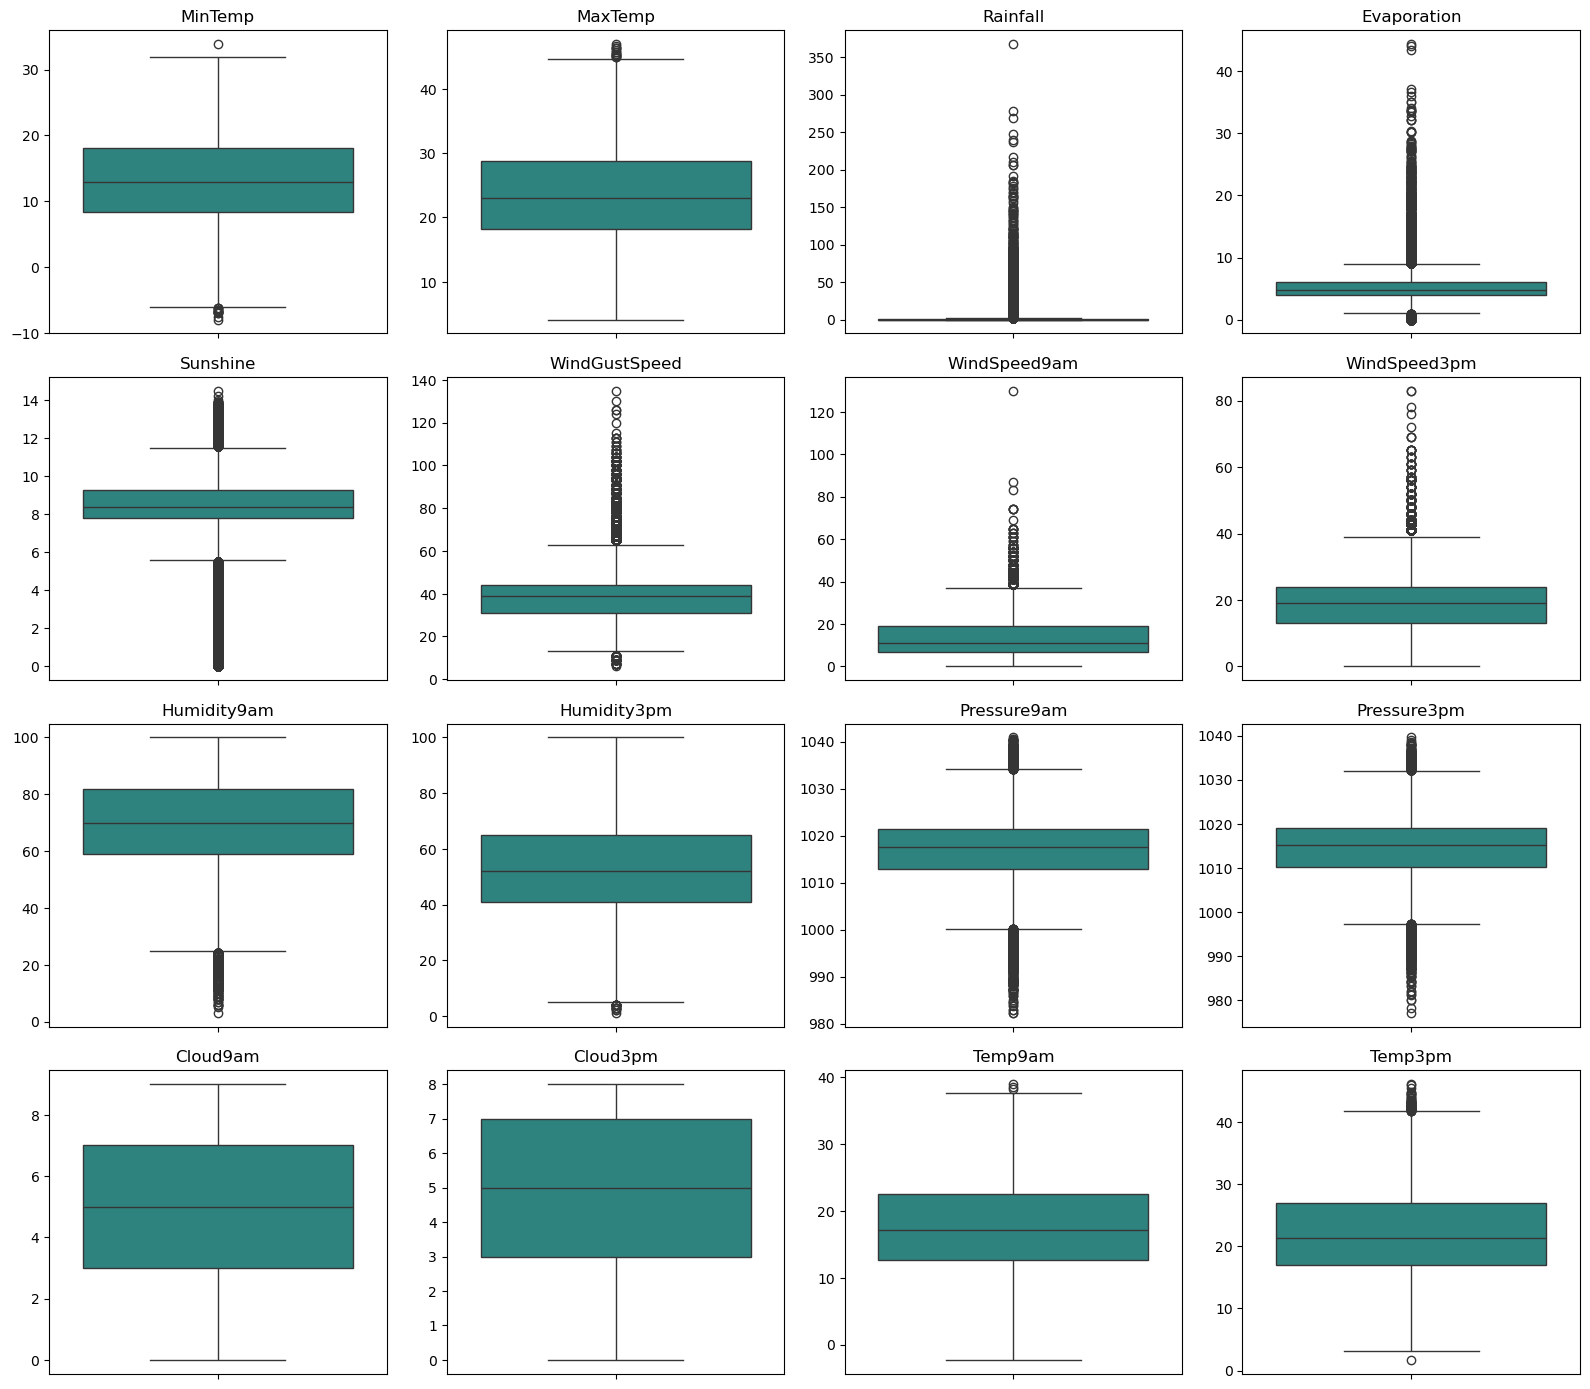

In [ ]:
col_num_data_aus = [
    'MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation',
    'Sunshine', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm',
    'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm',
    'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm'
]

fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(16, 14))
axes = axes.flatten()

for i, col in enumerate(col_num_data_aus):
    sns.boxplot(y=data_aus[col], ax=axes[i], palette='viridis')
    axes[i].set_title(col)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

plt.tight_layout()
plt.show()

Como paso previo, también se procede a crear variables dummies con relación a las variables categóricas.

In [ ]:
cols_categ = ['WindGustDir', 'WindDir9am', 'WindDir3pm', 'season', 'region_cluster']
data_aus[cols_categ] = data_aus[cols_categ].astype(str)

In [ ]:
from sklearn.preprocessing import OneHotEncoder

In [ ]:
ohe = OneHotEncoder(drop='first', sparse_output=False)
cols_enc = ohe.fit_transform(data_aus[cols_categ])


In [ ]:
# Nuevo dataframe con datos encoder
ohe_nombres = ohe.get_feature_names_out(cols_categ)
data_aus_ohe = pd.DataFrame(cols_enc, columns=ohe_nombres, index=data_aus.index)

In [ ]:
# Se unen cols numéricas con datos encoder
data_procesada = data_aus.drop(columns=cols_categ)
data_final = pd.concat([data_procesada, data_aus_ohe], axis=1)

Con el fin de chequear la relación entre las variables numéricas hasta ahora, se verifica la correlación entre ellas y con **RainTomorrow** y **RainToday**. Esto permitirá eliminar columnas antes del desarrollo del modelo predictivo.

In [ ]:
colum_numer_final = ['RainToday', 'RainTomorrow','MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine',
       'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am',
       'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm','Temp9am', 'Temp3pm']

corr_matrix = data_final[colum_numer_final].corr()

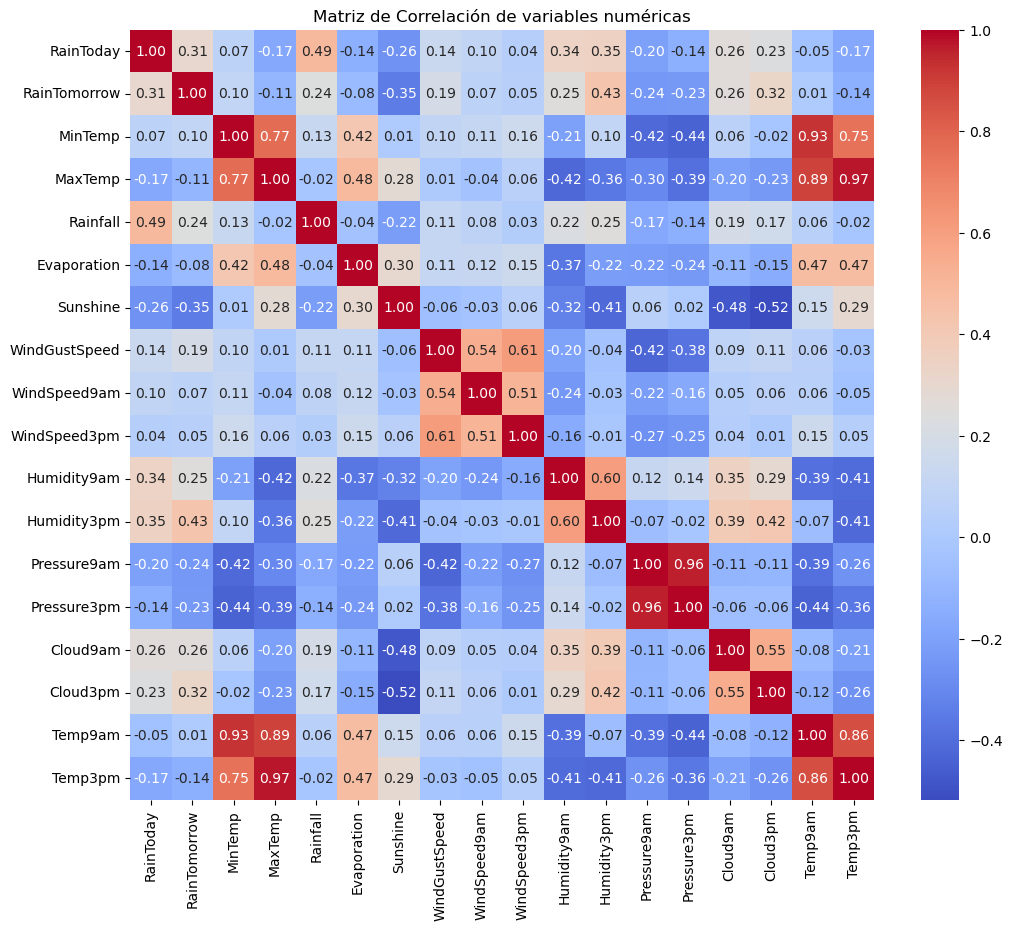

In [ ]:
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlación de variables numéricas')
plt.show()

La matriz muestra varios posibles casos de multicolinealidad. Se evalúa de forma más precisa.

In [ ]:
print("Análisis de alta correlación:")
high_corr = corr_matrix[abs(corr_matrix) > 0.8].stack().sort_values(ascending=False)
high_corr = high_corr[high_corr.index.get_level_values(0) != high_corr.index.get_level_values(1)]
high_corr = high_corr[high_corr < 1].drop_duplicates()
print(high_corr)

Análisis de alta correlación:
MaxTemp      Temp3pm        0.974839
Pressure9am  Pressure3pm    0.961190
MinTemp      Temp9am        0.928254
MaxTemp      Temp9am        0.887717
Temp9am      Temp3pm        0.863050
dtype: float64


### En el gráfico se muestra que MaxTemp y Temp3pm estan muy correlacionadas (MaxTemp toma la temperatura del dia, metrica mas general), al igual que Pressure9am y Pressure3pm (las dos toman presion atmosferica) y Temp9am y MinTemp (La temperatura minima es absoluta y coincide con la temperatura a las 9 que suele ser minima). Se eliminarán Temp9am, Temp3pm y Pressure3pm antes del split.

In [ ]:
data_final = data_final.drop(columns=['Temp9am', 'Temp3pm', 'Pressure3pm'])

#### Desarrollo de Modelo de Regresión Logística

In [ ]:

from sklearn.preprocessing import RobustScaler

In [ ]:
X = data_final.drop('RainTomorrow', axis=1)
Y = data_final['RainTomorrow']

Conjuntos a constituir:
- (X_train, y_train) (60% del total): Usado para el .fit() del modelo.
- (X_val, y_val) (20% del total): Usado para la validación cruzada (Cross-Validation) o para ajustar hiperparámetros.
- (X_test, y_test) (20% del total): Usado solo al final para reportar la métrica final (Accuracy, F1-Score, etc.).

In [ ]:
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, Y,
    test_size=0.2,   # 20% para el test set final
    random_state=42,
    stratify=Y)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val,
    test_size=0.25,   # 25% de X_train_val (que es 20% del total)
    random_state=42,
    stratify=y_train_val)

In [ ]:
print(f"Set de Train: {X_train.shape}")
print(f"Set de Validación: {X_val.shape}")
print(f"Set de Test: {X_test.shape}")

Set de Train: (33021, 67)
Set de Validación: (11008, 67)
Set de Test: (11008, 67)


Escalado de datos. Se decide hacerlo con RobustScaler, como se dijo más arriba.

In [ ]:
colum_escalar = ['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine',
    'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm',
    'Humidity9am', 'Humidity3pm', 'Pressure9am',
    'Cloud9am', 'Cloud3pm']

scaler = RobustScaler()

X_train[colum_escalar] = scaler.fit_transform(X_train[colum_escalar])

X_val[colum_escalar] = scaler.transform(X_val[colum_escalar])
X_test[colum_escalar] = scaler.transform(X_test[colum_escalar])

Validación cruzada sobre train y test.

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression

In [ ]:
lr = LogisticRegression(C=1.0, penalty='l2', solver='saga', max_iter=5000)

scores = cross_val_score(lr, X_train, y_train, cv=5, scoring='f1_weighted')

print(f"Scores de la Validación Cruzada: {scores}")
print(f"Promedio F1: {scores.mean():.4f}")

Scores de la Validación Cruzada: [0.82576347 0.82349361 0.82226206 0.8205131  0.83088839]
Promedio F1: 0.8246


Función para evaluar modelos:

In [ ]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, roc_auc_score)
from imblearn.over_sampling import SMOTE

In [ ]:
def evaluar_modelo(y_test, y_pred, y_proba, nombre_modelo):
    """Calcula métricas, grafica la matriz de confusión y la curva ROC."""

    # Métricas
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(f"Precision: {precision_score(y_test, y_pred):.4f}")
    print(f"Recall: {recall_score(y_test, y_pred):.4f}")
    print(f"F1 Score: {f1_score(y_test, y_pred):.4f}")
    print(f"AUC-ROC: {roc_auc_score(y_test, y_proba):.4f}")

    # Matriz de Confusión
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(15, 6))

    # Gráfico de Matriz de Confusión
    plt.subplot(1, 2, 1)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Lluvia', 'Lluvia'],
                yticklabels=['No Lluvia', 'Lluvia'])
    plt.ylabel('Etiqueta Verdadera')
    plt.xlabel('Predicción del Modelo')
    plt.title(f'Matriz de Confusión: {nombre_modelo}')

    # Análisis de Falsos
    TN, FP, FN, TP = cm.ravel()
    print("\nAnálisis de Falsos:")
    print(f"Verdaderos Positivos (TP - Aciertos 'Sí'): {TP}")
    print(f"Verdaderos Negativos (TN - Aciertos 'No'): {TN}")
    print(f"Falsos Positivos (FP - Error Tipo I): {FP}")
    print(f"Falsos Negativos (FN - Error Tipo II): {FN}")

    # Interpretación de Falsos:
    print("\nInterpretación:")
    print(f"FP ({FP}): El modelo predijo 'Lluvia', pero la realidad fue 'No Lluvia'.")
    print(f"FN ({FN}): El modelo predijo 'No Lluvia', pero la realidad fue 'Lluvia'.")

    # Curva ROC
    fpr, tpr, thresholds = roc_curve(y_test, y_proba)
    plt.subplot(1, 2, 2)
    plt.plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_test, y_proba):.4f}')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Tasa de Falsos Positivos (FPR)')
    plt.ylabel('Tasa de Verdaderos Positivos (TPR) - Recall')
    plt.title(f'Curva ROC: {nombre_modelo}')
    plt.legend(loc="lower right")

    plt.tight_layout()
    plt.show()

    # Cálculo del Mejor Umbral (Ejemplo: maximizando la F1-Score)
    print("\nAnálisis de Umbrales:")
    f1_scores = [(f1_score(y_test, y_proba > t), t) for t in thresholds]
    best_f1_score, best_threshold = max(f1_scores)

    print(f"El umbral que maximiza F1-Score es: {best_threshold:.4f} (F1: {best_f1_score:.4f})")


**Modelo 1:** Regresión logística base

Accuracy: 0.8385
Precision: 0.7220
Recall: 0.4725
F1 Score: 0.5712
AUC-ROC: 0.8598

Análisis de Falsos:
Verdaderos Positivos (TP - Aciertos 'Sí'): 1184
Verdaderos Negativos (TN - Aciertos 'No'): 8046
Falsos Positivos (FP - Error Tipo I): 456
Falsos Negativos (FN - Error Tipo II): 1322

Interpretación:
FP (456): El modelo predijo 'Lluvia', pero la realidad fue 'No Lluvia'.
FN (1322): El modelo predijo 'No Lluvia', pero la realidad fue 'Lluvia'.


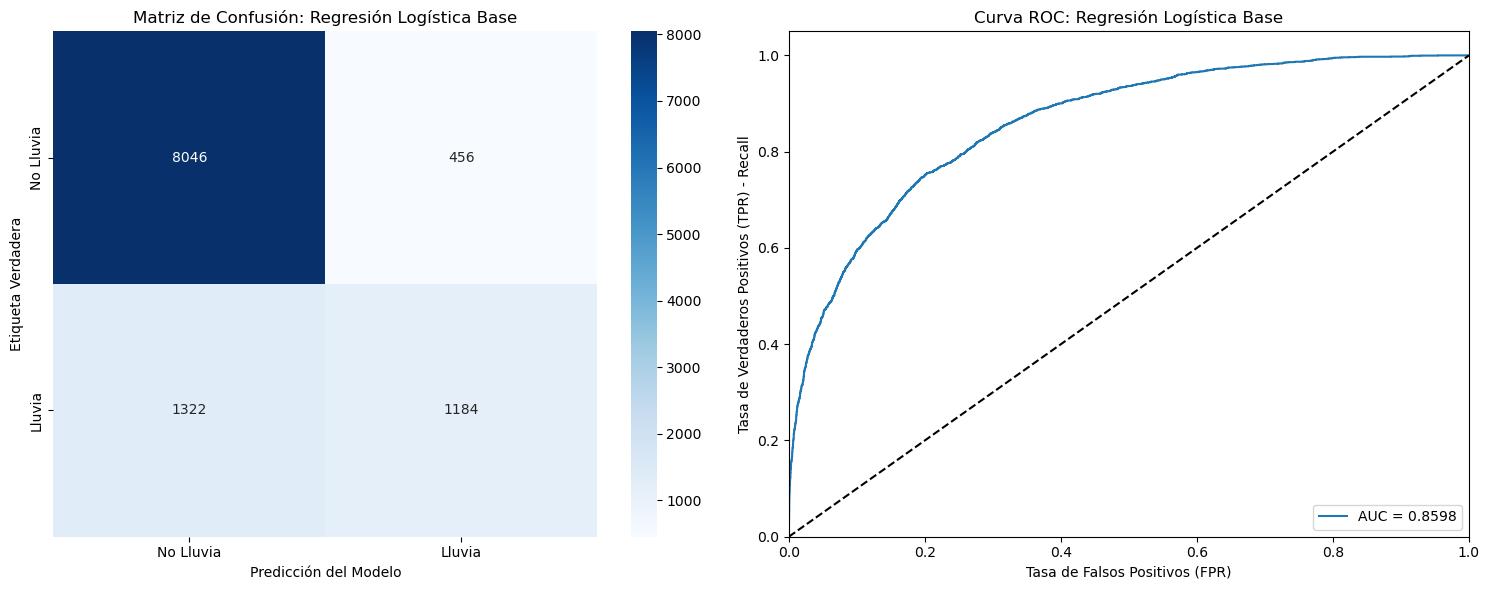


Análisis de Umbrales:
El umbral que maximiza F1-Score es: 0.2591 (F1: 0.6214)


In [ ]:
lr_base = LogisticRegression(solver='liblinear', random_state=42) # Usamos liblinear por consistencia

lr_base.fit(X_train, y_train)

# Predicciones con el X_test
y_pred_base = lr_base.predict(X_test)
y_proba_base = lr_base.predict_proba(X_test)[:, 1]

evaluar_modelo(y_test, y_pred_base, y_proba_base, "Regresión Logística Base")

**Modelo 2**: Regresión Logística con SMOTE

Accuracy: 0.7833
Precision: 0.5166
Recall: 0.7518
F1 Score: 0.6124
AUC-ROC: 0.8591

Análisis de Falsos:
Verdaderos Positivos (TP - Aciertos 'Sí'): 1884
Verdaderos Negativos (TN - Aciertos 'No'): 6739
Falsos Positivos (FP - Error Tipo I): 1763
Falsos Negativos (FN - Error Tipo II): 622

Interpretación:
FP (1763): El modelo predijo 'Lluvia', pero la realidad fue 'No Lluvia'.
FN (622): El modelo predijo 'No Lluvia', pero la realidad fue 'Lluvia'.


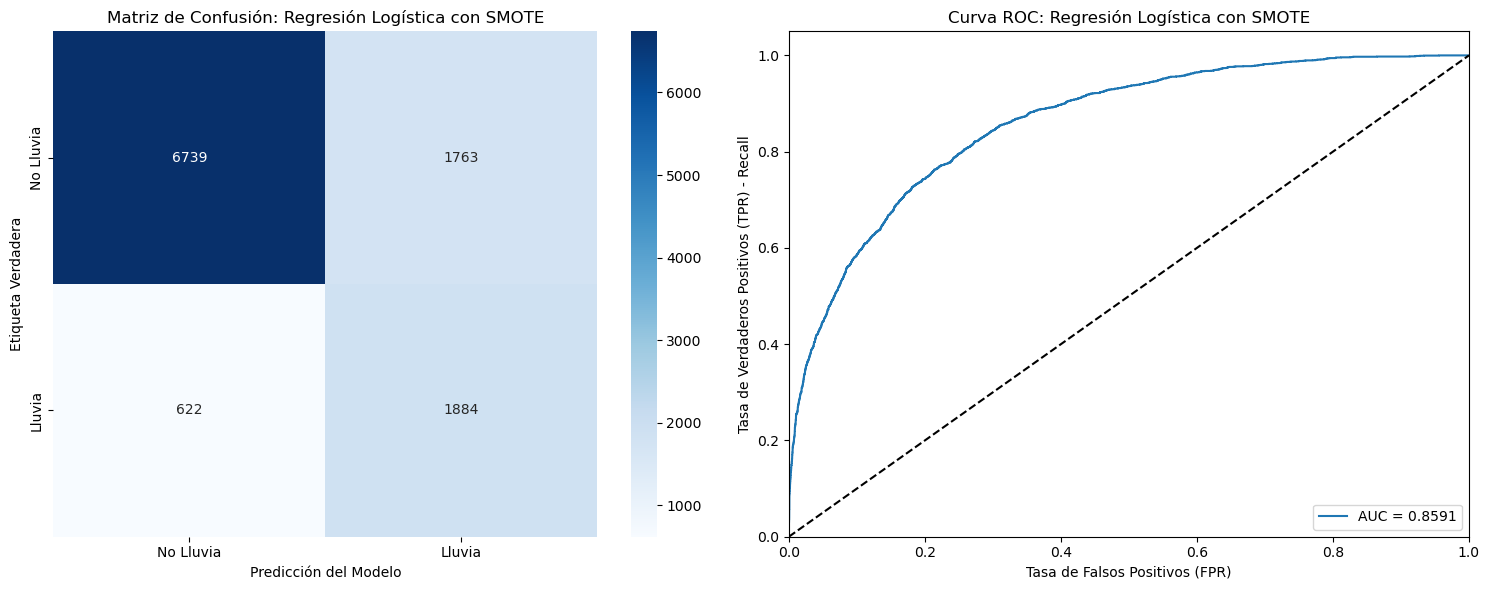


Análisis de Umbrales:
El umbral que maximiza F1-Score es: 0.5508 (F1: 0.6213)


In [ ]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

lr_smote = LogisticRegression(solver='liblinear', random_state=42)

# Entrenamiento con los datos balanceados (SMOTE)
lr_smote.fit(X_train_smote, y_train_smote)

y_pred_smote = lr_smote.predict(X_test)
y_proba_smote = lr_smote.predict_proba(X_test)[:, 1]

# Evaluación
evaluar_modelo(y_test, y_pred_smote, y_proba_smote, "Regresión Logística con SMOTE")

**Interpretación de Umbrales:**

0.5 no es el mejor umbral, es simplemente el valor por defecto que usa la función .predict(). Nuestros resultados demuestran:

Para el Modelo 1 (Base), el umbral de 0.5 da un F1-Score de 0.5712, pero el umbral óptimo (0.2591) da un F1-Score de 0.6214. Por lo tanto, 0.5 no es el mejor. Por otro lado, para el Modelo 2 (SMOTE), el umbral de 0.5 da un F1-Score de 0.6124, mientras que el óptimo (0.5496) da 0.6214. 0.5 es casi el mejor, pero no exactamente.

**Interpretación sobre el fitting**

**Modelo 1**: Mal Fitting
Este modelo sufre de un mal fitting porque está sesgado por los datos desbalanceados. Es muy bueno prediciendo "No Lluvia" (8046 aciertos), pero malo prediciendo "Lluvia". Esto lo demuestra que tiene 1322 Falsos Negativos (FN). Esto significa que falló en predecir la lluvia 1322 veces. Su Recall es muy bajo: solo 47.2% (1184 / (1184 + 1322)).

**Conclusión**: El modelo tiene underfitting para la clase "Lluvia", que es la que nos importa.

**Modelo 2**: Buen Fitting
Este modelo representa un fitting mucho mejor y más balanceado. Al usar SMOTE, se balanceó el set de entrenamiento, forzando al modelo a aprender a identificar la lluvia. Esto se demuestra en los Falsos Negativos (FN) ya que se redujeron a más de la mitad (de 1322 a 622). El modelo ahora predice correctamente la lluvia el 75.2% de las veces (Recall = 1884 / (1884 + 622)).

**Conclusión**: Aunque esto aumentó los Falsos Positivos, se logró el objetivo principal: se corrigió el mal ajuste del primer modelo y se creó un modelo que es mucho más útil para predecir la lluvia.

---

Estimados, van algunos comentarios sobre su primera entrega del trabajo práctico 2.

- La imputación por mediana es probablemente demasiado simple para este caso. Consideren analizar otros métodos.

- Las distribuciones de cada variable se deben visualizar antes y después de imputar (especialmente si la imputación es tan simple).

- Las ciudades están todas en Australia. Están tomando ciudades de nombres parecidos de otros países (o lo que su algoritmo mide como lo más cercano). Corregir.

- Revisar notebook ‘correlación.ipynb’ de la unidad 0 antes de decidir si dropear temperaturas por correlación.

- Faltaría un análisis de outliers.

- Si hacen el split después de imputar, analizar outliers, efectuar ingeniería de características y evaluar correlación, están con fuga de datos extremadamente alta.

- Veo utilizan scoring='f1_weighted' pero no veo donde justifican usar esa métrica. Esta parte es muy importante.

- Tampoco hay justificación para cambiar de solver, por qué cambian el default?

- Pueden probar regularización en la regresión logística.

- Pueden probar más métodos de balanceo, ya que demuestra subir su métrica. 


